In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load()
    + PyPDFLoader("./documents/book2.pdf").load()
    + PyPDFLoader("./documents/book3.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [4]:
# embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
from langchain_ollama import OllamaEmbeddings
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [5]:
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
from langchain_ollama import ChatOllama
llm = ChatOllama(model="deepseek-v3.2:cloud", temperature=0)

In [6]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [7]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [8]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [9]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

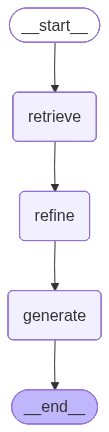

In [10]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [11]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

Based on the provided context:

- **Bias** is defined as the difference between the expected value of an estimator and the true parameter: bias(ˆθ_m) = (E[ˆθ_m]) − θ.
- **Trade-off Relationship**: There is a trade-off between bias and variance.
    - Increasing a parameter (like α) can reduce a model's variance but increases its bias.
    - Very flexible models tend to have **low bias** but **high variance**.
    - Relatively rigid models tend to have **high bias** but **low variance**.
- **Optimization Goal**: The goal is to minimize expected loss, which is decomposed into bias², variance, and noise. The model with the best predictive capability achieves the best balance between bias and variance.


In [12]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

obtain an expression for the bias in the form
w0 = −wTm (4.34)
where we have used
N∑
n=1
tn = N1
N
N1
− N2
N
N2
=0 (4.35)
and where m is the mean of the total data set and is given by
m = 1
N
N∑
n=1
xn = 1
N (N1m1 + N2m2). (4.36)
After some straightforward algebra, and again making use of the choice of tn, the
second equation (4.33) becomesExercise 4.6
(
SW + N1N2
N SB
)
w = N(m1 − m2) (4.37)
where SW is deﬁned by (4.28), SB is deﬁned by (4.27), and we have substituted for
the bias using (4.34). Using (4.27), we note that SBw is always in the direction of
(m2 − m1). Thus we can write
w ∝ S−1
W (m2 − m1) (4.38)
where we have ignored irrelevant scale factors. Thus the weight vector coincides
with that found from the Fisher criterion. In addition, we have also found an expres-
sion for the bias valuew
0 given by (4.34). This tells us that a new vectorx should be
****************************************************************************************************
thepolynomialregressionexam

In [13]:
print(res['refined_context'])

5.4.2Bias Thebiasofanestimatorisdeﬁnedas: bias(ˆθm) = (Eˆθm)−θ (5.20) 124 increasing α leads to flatter (i.e., less extreme, more reasonable) predictions; this reduces the model’s variance but increases its bias.
Our goal is to minimize the expected loss, which we have decomposed into the sum of a (squared) bias, a variance, and a constant noise term.
As we shall see, there is a trade-off between bias and variance, with very ﬂexible models having low bias and high variance, and relatively rigid models having high bias and low variance.
The model with the optimal predictive capability is the one that leads to the best balance between bias and variance.


In [14]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [15]:
decompose_to_sentences("""A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text. It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data. Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training. This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.""")

['A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text.',
 'It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data.',
 'Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training.',
 'This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.']